In [1]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [2]:
!nvidia-smi

Thu Jun  4 22:59:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install nvcc4jupyter

In [4]:
%load_ext nvcc4jupyter


Detected platform "Colab". Running its setup...
Source files will be saved in "/tmp/tmpq8ps9d2z".


In [5]:
# Detect selected GPU and its NVIDA architecture:
import subprocess
gpu_info = subprocess.getoutput("nvidia-smi --query-gpu=name,compute_cap --format=csv,noheader,nounits")
if "not found" in gpu_info.lower(): raise RuntimeError("Error: No GPU found. Please select a GPU runtime environment.")
gpu_name, compute_cap = map(str.strip, gpu_info.split(','))
gpu_arch = f"sm_{compute_cap.replace('.', '')}"

print(f"{'GPU Name':<15}: {gpu_name}")
print(f"{'Architecture':<15}: {gpu_arch}")

GPU Name       : Tesla T4
Architecture   : sm_75


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
dataset_path = '/content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1'

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt
import os

print("TensorFlow Version Setup Done! Version:", tf.__version__)

TensorFlow Version Setup Done! Version: 2.20.0


In [9]:
import os

# We use the exact path straight to your Training Data folder
train_dir = '/content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/Rice leaf disease Dataset original/Training Data'

# Replace 'Validation Data' below if your actual folder is named something else (like 'val' or 'Testing Data')
val_dir = '/content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/Rice leaf disease Dataset original/Validation data'

print("Your Training Data Path is:", train_dir)
print("Your Validation Data Path is:", val_dir)

Your Training Data Path is: /content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/Rice leaf disease Dataset original/Training Data
Your Validation Data Path is: /content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/Rice leaf disease Dataset original/Validation data


In [10]:
IMG_HEIGHT = 227
IMG_WIDTH = 227
BATCH_SIZE = 32   # The model will look at 64 images at a time

print("Loading Training Data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True, # Shuffles the data so the model learns better
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

print("\nLoading Validation Data...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Let's see what classes (leaf diseases) the code found automatically!
class_names = train_dataset.class_names
print("\nClasses detected by the system:", class_names)
num_classes = len(class_names)

Loading Training Data...
Found 1701 files belonging to 8 classes.

Loading Validation Data...
Found 186 files belonging to 8 classes.

Classes detected by the system: ['Bacterial Leaf Blight', 'Brown Spot', 'Healthy Rice Leaf', 'Leaf Blast', 'Leaf scald', 'Narrow Brown Leaf Spot', 'Rice Hispa', 'Sheath Blight']


In [11]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
print("Dataset pipeline optimized for speed!")

Dataset pipeline optimized for speed!


In [12]:
# Added Data Augmentation to help the model learn from different angles
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
])

model = Sequential([
    # Step 1: Augment Data & Normalize pixel values
    data_augmentation,
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # 1st Convolutional Layer
    Conv2D(filters=96, kernel_size=(11,11), strides=(4,4), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    # 2nd Convolutional Layer
    Conv2D(filters=256, kernel_size=(5,5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    # 3rd, 4th, 5th Convolutional Layers
    Conv2D(filters=384, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=384, kernel_size=(3,3), padding='same', activation='relu'),
    Conv2D(filters=256, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    Flatten(),

    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

print("Updated AlexNet Architecture Ready!")

Updated AlexNet Architecture Ready!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
from tensorflow.keras.optimizers import Adam

# We are lowering the learning rate from the default 0.001 to 0.0001
custom_optimizer = Adam(learning_rate=0.0001)

model.compile(optimizer=custom_optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model compiled with lower learning rate!")

Model compiled with lower learning rate!


In [14]:
EPOCHS = 30

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 48s 612ms/step - accuracy: 0.2640 - loss: 2.0708 - val_accuracy: 0.1989 - val_loss: 2.0544
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 635ms/step - accuracy: 0.4203 - loss: 1.5795 - val_accuracy: 0.1129 - val_loss: 2.0641
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 609ms/step - accuracy: 0.4974 - loss: 1.4141 - val_accuracy: 0.1129 - val_loss: 2.1493
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 34s 641ms/step - accuracy: 0.5285 - loss: 1.3059 - val_accuracy: 0.1559 - val_loss: 2.4066
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 39s 607ms/step - accuracy: 0.5444 - loss: 1.2559 - val_accuracy: 0.1667 - val_loss: 2.5953
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 33s 611ms/step - accuracy: 0.5967 - loss: 1.1310 - val_accuracy: 0.1989 - val_loss: 2.7658
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 607ms/step - accuracy: 0.6026 - loss: 1.1160 - val_accuracy: 0.3011 - val_loss: 1.8662
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 608ms/step - accuracy: 0.6461 - loss: 1.0238 - val_accu

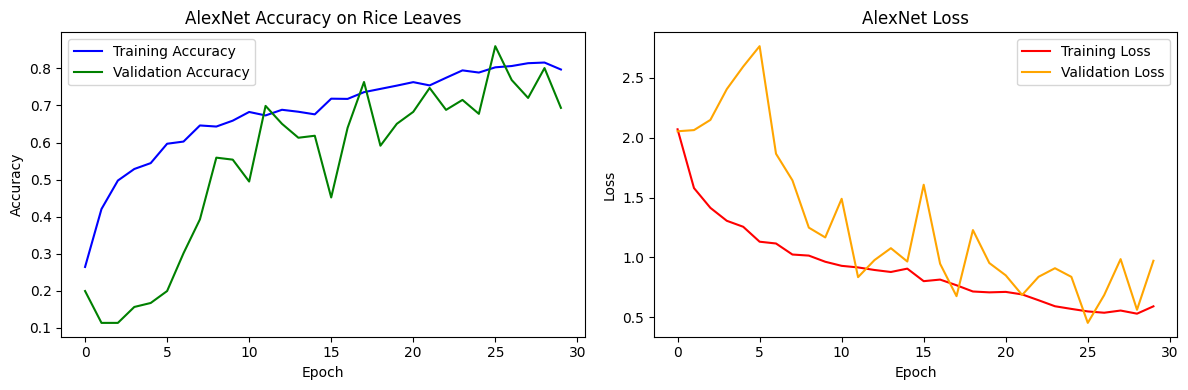

In [15]:
# Plotting Training vs Validation Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='green')
plt.title('AlexNet Accuracy on Rice Leaves')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Plotting Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('AlexNet Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

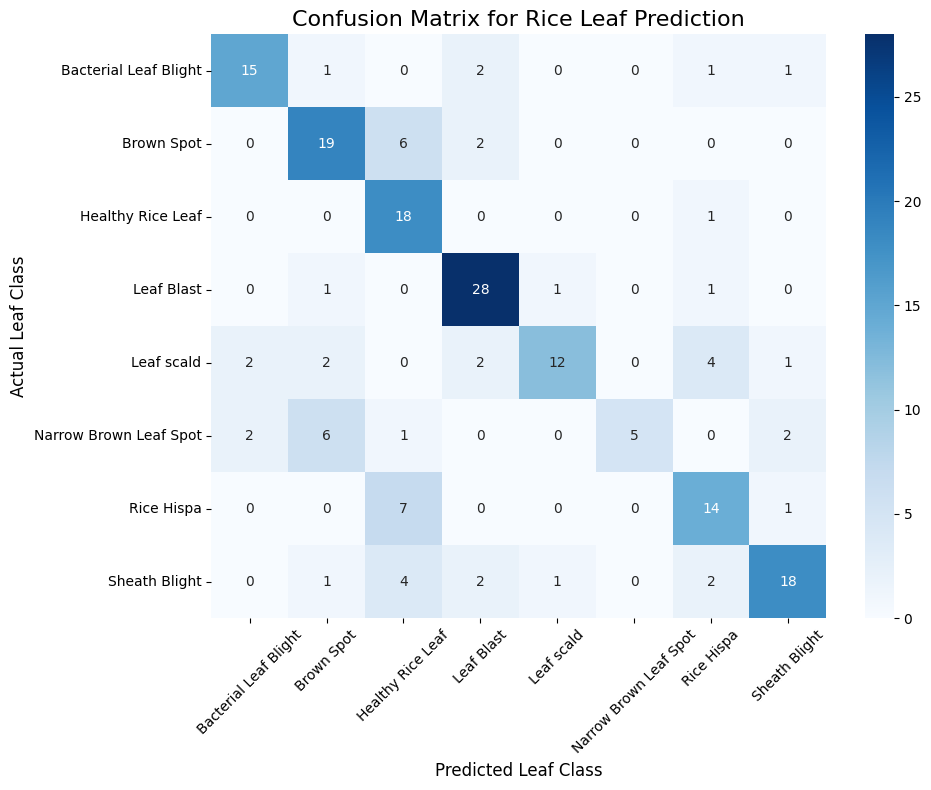


📝 Detailed Classification Report:

                        precision    recall  f1-score   support

 Bacterial Leaf Blight       0.79      0.75      0.77        20
            Brown Spot       0.63      0.70      0.67        27
     Healthy Rice Leaf       0.50      0.95      0.65        19
            Leaf Blast       0.78      0.90      0.84        31
            Leaf scald       0.86      0.52      0.65        23
Narrow Brown Leaf Spot       1.00      0.31      0.48        16
            Rice Hispa       0.61      0.64      0.62        22
         Sheath Blight       0.78      0.64      0.71        28

              accuracy                           0.69       186
             macro avg       0.74      0.68      0.67       186
          weighted avg       0.74      0.69      0.69       186



In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report



# 1. Create empty lists to store true labels and predicted labels
y_true = []
y_pred = []

# 2. Loop through the validation dataset batch by batch
for images, labels in val_dataset:
    # Get model predictions for this batch
    batch_predictions = model.predict(images, verbose=0)

    # Convert probabilities to exact class numbers (0, 1, 2, etc.)
    batch_predicted_classes = np.argmax(batch_predictions, axis=1)

    # Store the true and predicted labels
    y_pred.extend(batch_predicted_classes)
    y_true.extend(labels.numpy())

# 3. Generate the Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 4. Plot the Confusion Matrix using Seaborn for a beautiful heat map
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix for Rice Leaf Prediction', fontsize=16)
plt.ylabel('Actual Leaf Class', fontsize=12)
plt.xlabel('Predicted Leaf Class', fontsize=12)
plt.xticks(rotation=45) # Rotates the text so it doesn't overlap
plt.tight_layout()
plt.show()

# 5. Print a detailed text report
print("\n📝 Detailed Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

In [17]:
save_path = os.path.join(dataset_path, 'rice_leaf_alexnet_model.keras')
model.save(save_path)
print(f"Model saved successfully at: {save_path}")

Model saved successfully at: /content/drive/MyDrive/Colab Notebooks/SUBHAJIT_PHASE 1/rice_leaf_alexnet_model.keras
